In [15]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_auc_score

import joblib

import matplotlib.pyplot as plt

!pip install shap
import shap

Cargando datos

In [7]:
data = pd.read_csv("C:/Users/david/Desktop/master/TFM/CSV/df_combinado_score_imputado_ES.csv", index_col=0)

data = data.drop(columns=['PATNO', 'Unnamed: 0', 'grupo de estudio', 'CLINICAL_EVENT'])

data= data[data['estado SAA'].isin(['Positivo', 'Negativo'])]
data = data.dropna(axis=1)


print(f"Data dimensions: {data.shape}")
print(f"Data target distribution:\n{data['estado SAA'].value_counts(dropna=False)}")

data

Data dimensions: (1041, 15)
Data target distribution:
estado SAA
Positivo    617
Negativo    424
Name: count, dtype: int64


,edad en momento baseline,grupo de edad,sexo,etnia,raza,estado SAA,mutación GBA,mutación LRRK2,mutación SNCA,mutación APOE_E4,mutación EP,valor MDS UPDRS III,Estadío Hoehn & Yahr,valor MoCA,protocolo
0,73.0,70-79,Mujer,No hispano o latino,Blanca,Positivo,No,No,No,Sí,Sí,2.0,0.0,27.0,24h
1,66.0,60-69,Mujer,No hispano o latino,Blanca,Positivo,No,No,No,Sí,Sí,2.0,0.0,28.0,24h
2,67.0,60-69,Hombre,No hispano o latino,Blanca,Positivo,No,No,No,No,No,0.0,0.0,26.0,24h
3,76.0,70-79,Mujer,No hispano o latino,Blanca,Positivo,No,No,No,No,No,4.0,0.0,25.0,24h
4,62.0,60-69,Mujer,No hispano o latino,Blanca,Positivo,No,No,No,Sí,Sí,2.0,0.0,27.0,24h
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1036,82.0,≥80,Hombre,No hispano o latino,Blanca,Negativo,No,No,No,No,No,4.0,0.0,24.0,150h
1037,67.0,60-69,Hombre,Hispano o latino,Desconocida,Positivo,No,No,No,Sí,Sí,0.0,0.0,29.0,150h
1038,74.0,70-79,Hombre,No hispano o latino,Blanca,Negativo,No,No,No,No,No,2.0,0.0,26.0,150h
1039,72.0,70-79,Hombre,No hispano o latino,Blanca,Positivo,No,No,No,No,No,0.0,0.0,28.0,150h


Preprocesado

In [8]:
# Codificar variables categóricas
categorical_columns = data.select_dtypes(include=['object']).columns.tolist()
if 'grupo de estudio' in categorical_columns:
    categorical_columns.remove('grupo de estudio')

print(f"Variables categóricas a codificar: {categorical_columns}")

# Codificar variables categóricas con LabelEncoder
label_encoders = {}
for col in categorical_columns:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col].astype(str))
    label_encoders[col] = le

Variables categóricas a codificar: ['grupo de edad', 'sexo', 'etnia', 'raza', 'estado SAA', 'mutación GBA', 'mutación LRRK2', 'mutación SNCA', 'mutación APOE_E4', 'mutación EP', 'protocolo']


Splitting data

In [9]:
X = data.drop(columns=['estado SAA'])
y = data['estado SAA']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=123, stratify=y
)

# IMPORTANT: "Case" as positive class
#y_train = (y_train == "Positive").astype(int)
#y_test = (y_test == "Positive").astype(int)

print(f"Train dimensions: {X_train.shape}, Test dimensions: {X_test.shape}")

data.to_csv("dataset prueba pipeline.csv")

Train dimensions: (832, 14), Test dimensions: (209, 14)


Creando modelo

In [10]:
param_grid = {
    "criterion": ["gini"],
    'n_estimators': [100],
    'max_depth': [None],
    'max_features': ['sqrt']
}

ranger_model = RandomForestClassifier(
    random_state=123,
    n_jobs=-1,
    oob_score=False
)

cv = GridSearchCV(
    estimator=ranger_model,
    param_grid=param_grid,
    scoring='balanced_accuracy',
    n_jobs=-1,
    cv=5,
    verbose=1
)

cv.fit(X_train, y_train)

Fitting 5 folds for each of 1 candidates, totalling 5 fits


,estimator,RandomForestC...dom_state=123)
,param_grid,"{'criterion': ['gini'], 'max_depth': [None], 'max_features': ['sqrt'], 'n_estimators': [100]}"
,scoring,'balanced_accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,100


In [11]:
joblib.dump(cv.best_estimator_, r"C:\Users\david\Desktop\master\TFM\Script\ranger_model.joblib")

['C:\\Users\\david\\Desktop\\master\\TFM\\Script\\ranger_model.joblib']

In [12]:
ranger_model = joblib.load(r"C:\Users\david\Desktop\master\TFM\Script\ranger_model.joblib")

In [13]:
print("Best params:", cv.best_params_)
print("Best balanced accuracy:", round(cv.best_score_, 3))

Best params: {'criterion': 'gini', 'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 100}
Best balanced accuracy: 0.849


Predict on test

In [16]:
y_pred = ranger_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred, labels=np.unique(y_test))
print(pd.DataFrame(cm, index=np.unique(y_test), columns=np.unique(y_test)))

print("\nClassification report:")
print(classification_report(y_test, y_pred))
auc = roc_auc_score(y_test, ranger_model.predict_proba(X_test)[:, 1])
print(f'AUC-ROC: {round(auc, 3)}')

    0    1
0  68   17
1  13  111

Classification report:
              precision    recall  f1-score   support

           0       0.84      0.80      0.82        85
           1       0.87      0.90      0.88       124

    accuracy                           0.86       209
   macro avg       0.85      0.85      0.85       209
weighted avg       0.86      0.86      0.86       209

AUC-ROC: 0.905


Variable Importance

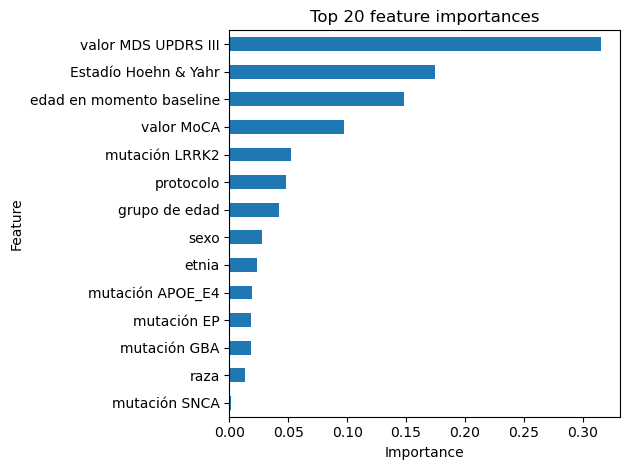

In [17]:
importances = ranger_model.feature_importances_
feat_imp = pd.Series(importances, index=X_train.columns).sort_values(ascending=False)

top_n = 20
top_feat = feat_imp.head(top_n)

plt.figure()
top_feat.iloc[::-1].plot(kind='barh')
plt.title(f"Top {top_n} feature importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

### SHAP

SHAP está basada en la teoría de juegos y trata a los modelos de clasificación como "cajas negras" que producen una salida con una cierta probabilidad.

La función básica de SHAP que obtiene una explicabilidad independientemente del modelo es "shap.Explainer". El mayor inconveniente de esa función es que tarda mucho.

SHAP proporciona ciertos explainers que tienen en cuenta características de los modelos. Por ejemplo, LinearExplainer está especialmente implementado para modelos lineales.

Al usar un modelo de Random Forest, podemos usar "TreeExplainer".

In [18]:
explainer = shap.TreeExplainer(ranger_model)
shap_values = explainer.shap_values(X_test)

Shap BEESWARM

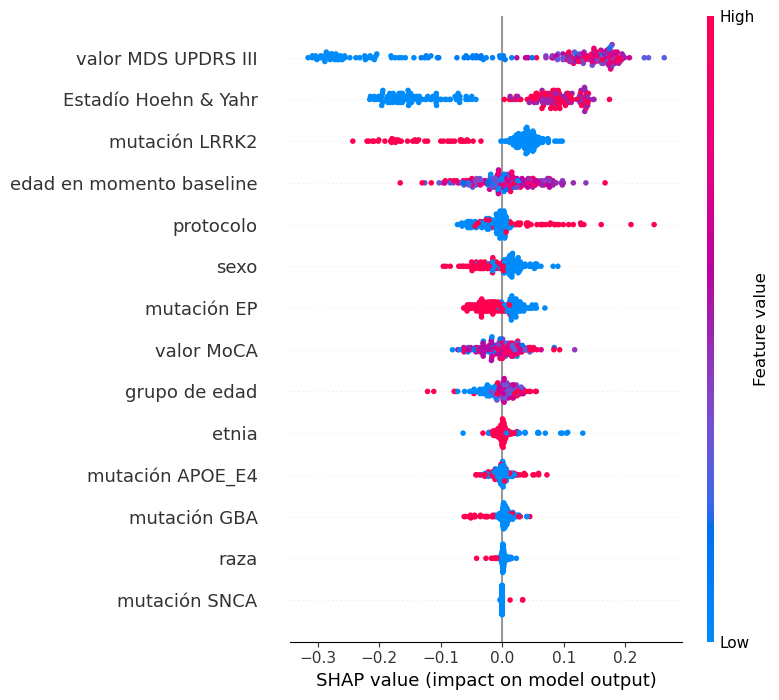

In [19]:
# Al poner "shap_values[:, :, 1]" vemos la probabilidad de la clase positiva
# Valores del eje X > 0.5 son de la clase positiva
# Valores del eje X < 0.5 son de la clase negativa
shap_values_pos = shap_values[:, :, 1]
shap.summary_plot(shap_values_pos, X_test, plot_type="dot")

SHAP for a individual (e.g., PP-50172)

In [20]:
df = pd.DataFrame({
    "y_test" : y_test,
    "y_pred" : y_pred
})

df.head(5)

,y_test,y_pred
298,1,1
1030,1,1
484,0,0
1022,1,0
887,0,0


Voy a mostrar el plot de cascada para el individuo "0"

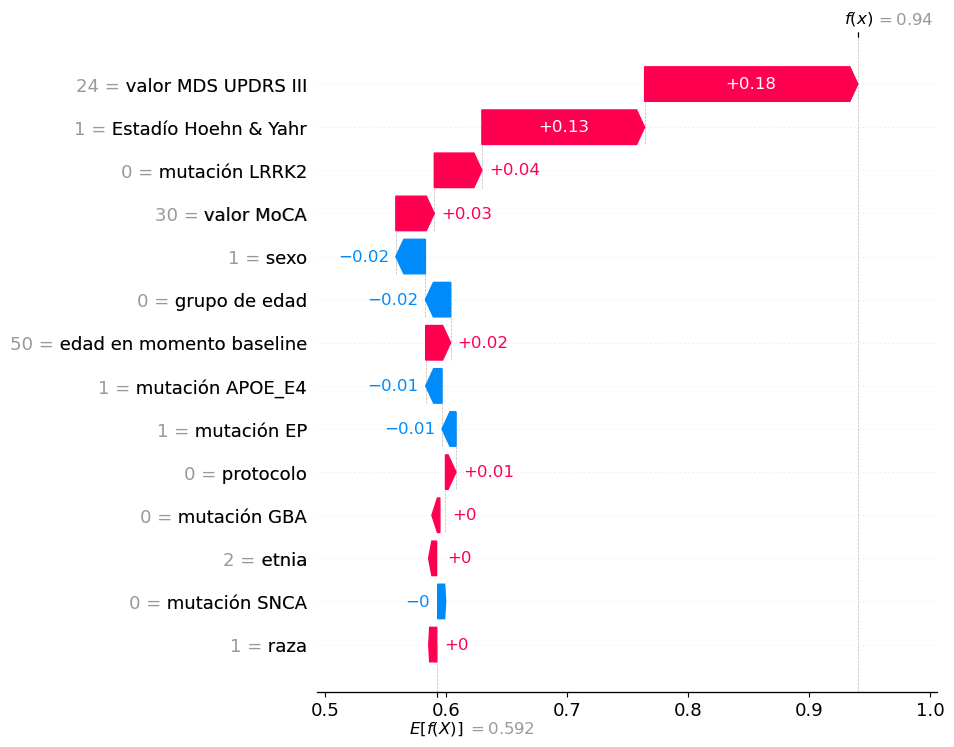

In [21]:
i = 0

# Al poner "shap_values[i, :, 1]" vemos la probabilidad de la clase positiva
# Valores del eje X > 0.5 son de la clase positiva
# Valores del eje X < 0.5 son de la clase negativa
shap_values_i = shap_values[i, :, 1]

exp = shap.Explanation(
    values=shap_values_i,
    base_values=explainer.expected_value[1],
    data=X_test.iloc[i],
    feature_names=X_test.columns
)

shap.plots.waterfall(exp, max_display=20)

Lo realizamos para un individuo que haya sido predicho como clase negativa

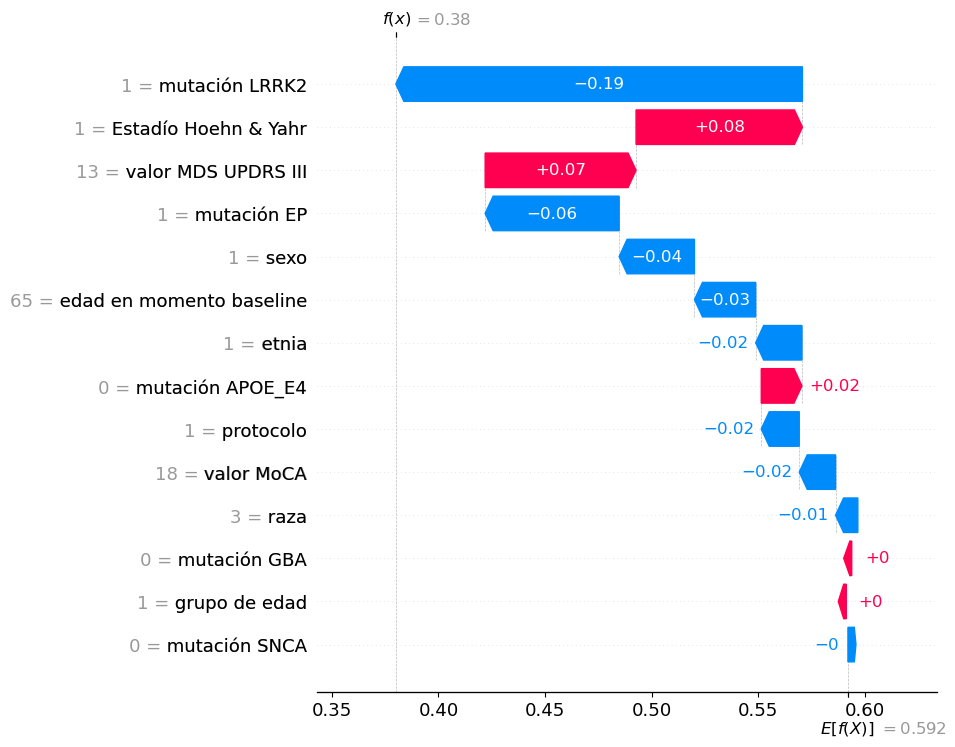

In [22]:
i = 16

shap_values_i = shap_values[i, :, 1]

exp = shap.Explanation(
    values=shap_values_i,
    base_values=explainer.expected_value[1],
    data=X_test.iloc[i],
    feature_names=X_test.columns
)

shap.plots.waterfall(exp, max_display=20)

In [34]:
for i in [0, 16]:
    idx_real = X_test.index[i]
    print(f"=== i = {i} ===")
    print(data.loc[idx_real])
    print(f"SAA_Status real: {y_test.iloc[i]} ({'Positive' if y_test.iloc[i]==1 else 'Negative'})")
    print(f"SAA_Status predicho: {y_pred[i]} ({'Positive' if y_pred[i]==1 else 'Negative'})")
    print()

=== i = 0 ===
age_at_baseline                      80.0
age_group                             4.0
sex                                   1.0
ethnicity                             1.0
race                                  5.0
SAA_Status                            0.0
has_known_GBA_mutation_in_WGS         0.0
has_known_LRRK2_mutation_in_WGS       0.0
has_known_SNCA_mutation_in_WGS        0.0
has_known_APOE_E4_mutation_in_WGS     0.0
has_known_PD_Mutation_in_WGS          0.0
mds_updrs_part_iii_summary_score     28.0
code_upd2hy_hoehn_and_yahr_stage      2.0
moca_total_score                     27.0
protocolo                             1.0
Name: 4, dtype: float64
SAA_Status real: 0 (Negative)
SAA_Status predicho: 1 (Positive)

=== i = 16 ===
age_at_baseline                      61.0
age_group                             1.0
sex                                   0.0
ethnicity                             1.0
race                                  5.0
SAA_Status                            0.0
